# **Into the Job Market: Gender Fairness in Recruitment Dataset**

Alkmini Sapountzaki (alks@itu.dk), Caroline Sofie Skovby (cssk@itu.dk), Miriam Espinosa Solana (miri@itu.dk)

## Table of Contents
* [Imports and Data Loading](#imports)
* [Explanatory Analysis](#explanatory-analysis)
    * [Distribution of the attributes](#eda-attributes)
    * [Correlation between target and gender and other variables](#corr-gender-attr)
    * [Recruitment Outcome by Gender](#recr-outcome)
* [Data Preprocessing](data-preprocessing)
* [Baseline Model](#baseline-model)
    * [Training](#bm-train)
    * [Model Evaluation](#bm-model_evaluation)
    * [Fairness Evaluation](#bm-fairness-evaluation)
* [Fairness Intervention: Removing Gender Feature](#removing-gender)
    * [Training](#rg-train)
    * [Model Evaluation](#rg-model-evaluation)
    * [Fairness Evaluation](#rg-fairness-analysis)
* [Fairness Intervention: Fair PCA Transformation](#fair-pca)
    * [Baseline Correlation Analysis](#correlations-1)
    * [Fair PCA Implementation](#fair-pca-implementation)
    * [Post Transformation Correlations](#correlations-aft)
    * [Training & Model Evaluation](#fp-train-model-evaluation)
    * [Fairness Evaluation](#fp-fairness-evaluation)
* [Fair PCA Robustness: Effect of Gender Flipping on SHAP Explanations](#pca-robustness)
    * [Flip Gender in Test Data](#flip-gender)
    * [Model Evaluation](#fg-model-evaluation)
    * [Fairness Evaluation](#fg-fairness-evaluation)
    * [SHAP Comparison: Original vs Gender-Flipped Test Instances](#fg-shap)

## Imports and Data Loading <a class="anchor" id="imports"></a>

In [1030]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import shap 
import scipy


from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegressionCV
from sklearn.inspection import permutation_importance


In [1031]:
# Load the data 
df = pd.read_csv('data/recruitmentdataset-2022.csv')
df.head()

,Id,gender,age,nationality,sport,ind-university_grade,ind-debateclub,ind-programming_exp,ind-international_exp,ind-entrepeneur_exp,ind-languages,ind-exact_study,ind-degree,company,decision
0,x8011e,female,24,German,Swimming,70,False,False,False,False,1,True,phd,A,True
1,x6077a,male,26,German,Golf,67,False,True,False,False,2,True,bachelor,A,False
2,x6006e,female,23,Dutch,Running,67,False,True,True,False,0,True,master,A,False
3,x2173b,male,24,Dutch,Cricket,70,False,True,False,False,1,True,master,A,True
4,x6241a,female,26,German,Golf,59,False,False,False,False,1,False,master,A,True


In [1032]:
## One hot encode the categorical features
feature_names = [#'Id', # Id
                 "gender", # Gender - sensitive
                 'age', # age in years 
                 "nationality", # Nationality
                 'sport', # first/main sport listed on CV
                 'ind-university_grade', # University grade (percentage) of the canditate
                 "ind-debateclub", # whether candidate participated in debate club
                 "ind-programming_exp", # whether candidate has programming experience
                 'ind-international_exp', # whether candidate has international experience
                 "ind-entrepeneur_exp", # whether candidate has entrepeneur experience
                 "ind-languages", # Number of additional languages spoken fluently by candidate
                 'ind-exact_study', # whether candidate studied physics, engineering or other science-oriented study
                 'ind-degree', # highest completed degree. Phd, bachelor or master level
                 'company'] # The company the candidate applied to

target_name = "decision" # target value - wether the candidate got hired at the company or not

def data_processing(data, features, target_name:str):
    df = data
    ### Gender Filter
    df = df[df["gender"] != 'other'] # filter out 'other', to have binary gender

    ### Groups of interest
    sex = df["gender"].values

    ### Target
    df["target"] = df[target_name] # decision is target value
    target = df["target"].values

    #we want to keep df before one_hot encoding to make Bias Analysis - probably not relevant with decision being binary to begin with
    df = df[features + ["target", target_name]] 
    df_processed = df[features].copy()
    cols = [ "gender", "nationality", "sport", "ind-degree", "company"]
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=False, columns=cols, drop_first=False)

    # drop the categories that are most represented in the data only if not data preprocessing
    df_processed_analysis = df_processed.drop(columns=["sport_Football", "gender_male", "nationality_Dutch", "ind-degree_bachelor", "company_A"])

    return df_processed, df_processed_analysis, df, target, sex

data_eda, data, data_original, target, group = data_processing(df, feature_names, target_name)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    data, target, group, test_size=0.2, random_state=0)

/tmp/ipykernel_1547/1749571490.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target"] = df[target_name] # decision is target value


## Explanatory Data Analysis (EDA) <a class="anchor" id="explanatory-analysis"></a>

### Distribution of the attributes <a class="anchor" id="eda-attributes"></a>

In [1033]:
## Ignore the rows with other as gender 
df = df[df["gender"].str.lower() != "other"]

#### Binary Variables

In [1034]:
## Bar plot for binary variables
def make_barh(df, col, option_1, option_2, ax, title):

    ## Set colors 
    color_2 = "#53739E"
    color_1 = "#A59E9E"
    color_title = "#5E5F64"

    if col == "gender":
        keys, labels = [option_1, option_2], [option_1, option_2]
        counts = df[col].value_counts().reindex(keys, fill_value=0)
    else:
        keys, labels = [0, 1], [option_1, option_2]
        counts = df[col].astype(int).value_counts().reindex(keys, fill_value=0)

    pct = counts / counts.sum() * 100

    bar_height = 0.28

    ax.barh(y=0, width=pct[keys[0]], left=0, height=bar_height, color=color_1, edgecolor="white")
    ax.barh(y=0, width=pct[keys[1]], left=pct[keys[0]], height=bar_height, color=color_2, edgecolor="white")

    ax.text(pct[keys[0]] / 2, 0.32, f"{labels[0].capitalize()}\n{pct[keys[0]]:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold", color=color_1)
    ax.text(pct[keys[0]] + pct[keys[1]] / 2, 0.32, f"{labels[1].capitalize()}\n{pct[keys[1]]:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold", color=color_2)

    #ax.text(50, -0.28, title, ha="center", va="top", fontsize=13, color = color_title)
    #ax.set_title(title, fontsize=13, pad=20, color = color_title)
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.4, 0.9)
    ax.axis("off")

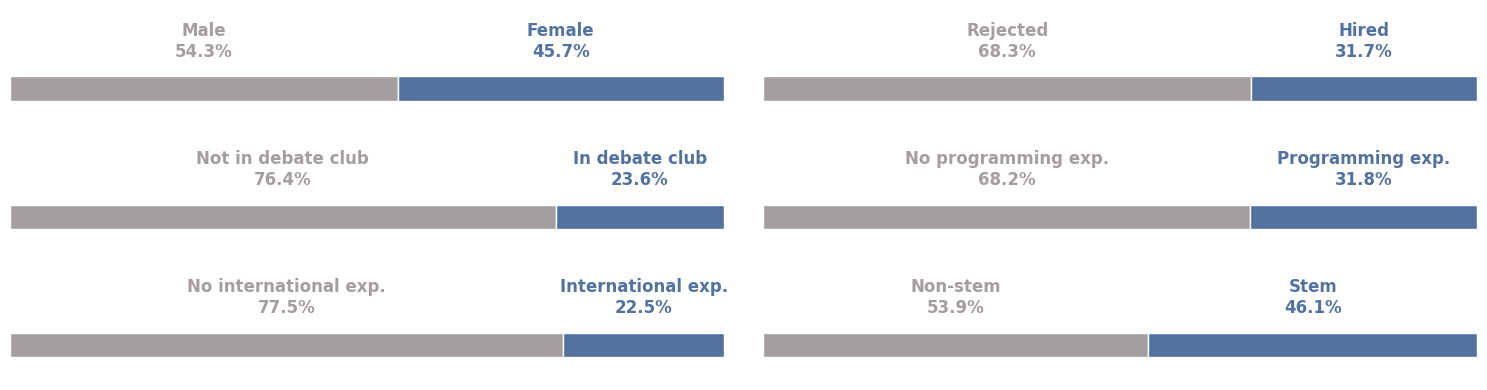

In [1035]:
fig, axes = plt.subplots(3, 2, figsize=(15, 4))
axes = axes.ravel()

colors = plt.get_cmap('Blues')(np.linspace(0.5, 0.9, 2))

make_barh(df, "gender", "male", "female", axes[0], "Gender Distribution")
make_barh(df, "decision", "Rejected", "Hired", axes[1], "Decision Distribution")
make_barh(df, "ind-debateclub", "Not in debate club", "In debate club", axes[2], "Debate Club Participation")
make_barh(df, "ind-programming_exp", "No programming exp.", "Programming exp.", axes[3], "Programming Experience")
make_barh(df, "ind-international_exp", "No international exp.", "International exp.", axes[4], "International Experience")
make_barh(df, "ind-exact_study", "Non-STEM", "STEM", axes[5], "STEM Background")

plt.tight_layout()
plt.show()

#### Continuous variables

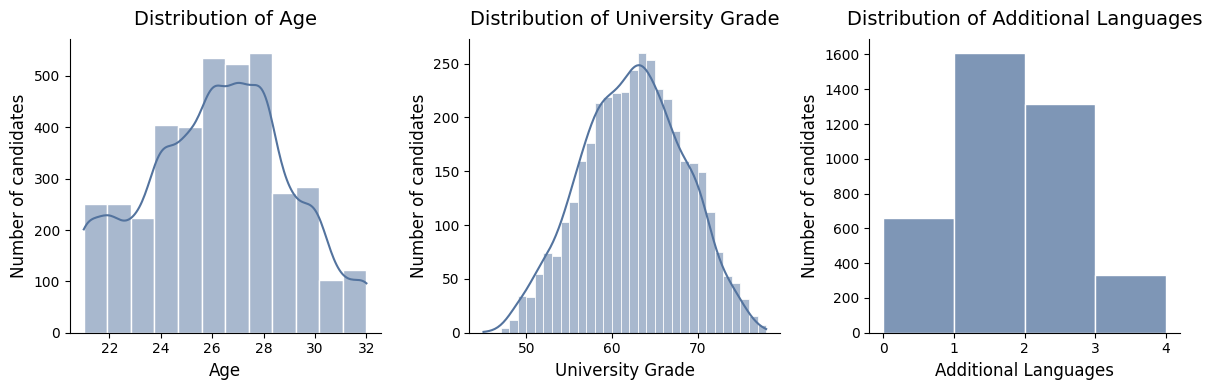

In [1036]:

continuous_cols = {
    "age": "Age",
    "ind-university_grade": "University Grade", 
    "ind-languages": "Additional Languages"
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (col, title) in zip(axes, continuous_cols.items()):
    if col != "ind-languages":
        sns.histplot(data=df,x=col, bins=df[col].nunique(), kde=True, edgecolor="white", ax=ax, color="#53739E")
    else:
        sns.histplot(data=df,x=col, bins=range(df[col].min(), df[col].max() + 2), kde=False, edgecolor="white", ax=ax, color="#53739E")
    ax.set_title(f"Distribution of {title}", fontsize=14, pad=10)
    ax.set_xlabel(title, fontsize=12)
    ax.set_ylabel("Number of candidates", fontsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

#### Categorical Variables

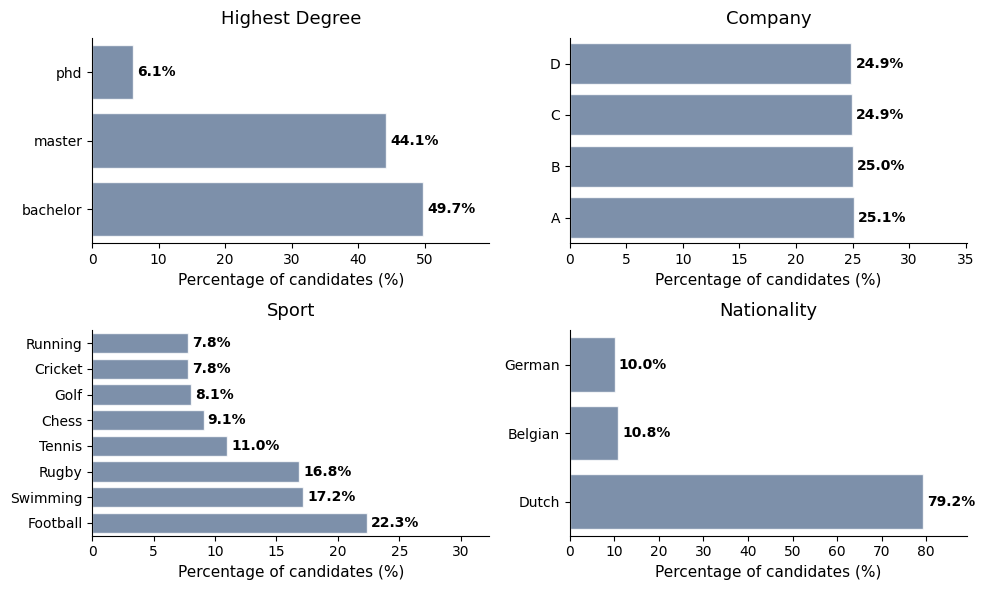

In [1037]:
categorical_cols = {
    "ind-degree": "Highest Degree",
    "company": "Company",
    "sport": "Sport",
    "nationality": "Nationality"
}


fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes = axes.ravel()
for ax, (col, title) in zip(axes, categorical_cols.items()):

    plot_df = (df[col].astype(str).value_counts(normalize=True).mul(100).reset_index())

    plot_df.columns = [col, "percentage"]
    plot_df = plot_df.sort_values("percentage", ascending=True)

    sns.barplot(data=plot_df,x="percentage",y=col,color="#53739E",edgecolor="white",ax=ax, alpha=0.8)

    for container in ax.containers:
        ax.bar_label(container,fmt="%.1f%%",padding=3,fontsize=10,fontweight="bold")

    ax.set_title(title, fontsize=13, pad=10)
    ax.set_xlabel("Percentage of candidates (%)", fontsize=11)
    ax.set_ylabel("")
    ax.set_xlim(0, plot_df["percentage"].max() + 10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Correlation between target and gender and other variables <a class="anchor" id="corr-gender-attr"></a>

In [1038]:
label_map = {
    "ind-languages": "Languages",

    "age": "Age",

    "ind-degree_phd": "PhD degree",
    "ind-degree_master": "Master degree",
    'ind-degree_bachelor': "Bachelor degree",

    "ind-debateclub": "Debate club",
    'ind-programming_exp': "Programming exp.",
    'ind-exact_study': "In STEM",
    "ind-entrepeneur_exp": "Entrepreneurship exp.",
    "ind-university_grade": "University grade",
    "ind-international_exp": "International exp.",
    
    'nationality_Belgian': "Belgian",
    'nationality_Dutch': "Dutch",
    'nationality_German': "German",

    'sport_Chess': "Chess",
    'sport_Cricket': "Cricket",
    'sport_Football': "Football",
    'sport_Golf': "Golf",
    'sport_Rugby': "Rugby",
    'sport_Running': "Running",
    'sport_Swimming': "Swimming",
    'sport_Tennis': "Tennis",

    'company_A': "Company A",
    "company_B": "Company B",
    "company_C": "Company C",
    "company_D": "Company D",

    'gender_male': "Male",
    "gender_female": "Female", 
    
    'decision': 'Decision'
    
}

data_eda['decision'] = target

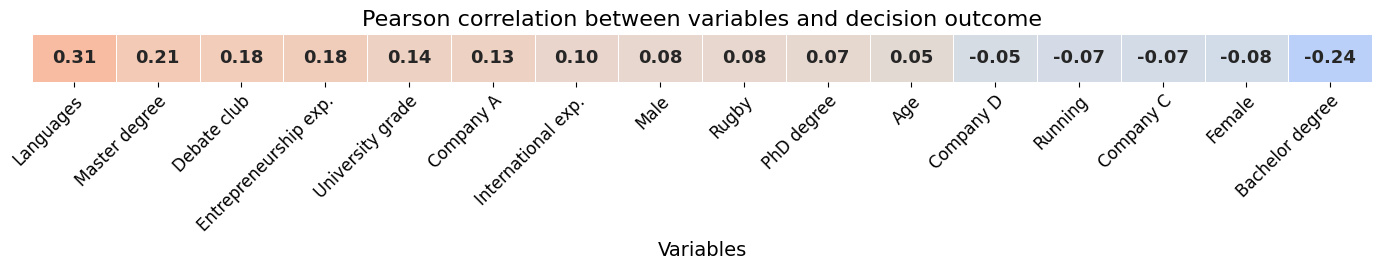

In [1039]:
### Correlation Matrix for target
target_col = "decision"

y = data_eda[target_col].astype(int)
X = data_eda.drop(columns=[target_col])


alpha = 0.05
corrected_alpha = alpha / X.shape[1]  # Bonferroni correction

results = []

for col in X.columns:
    x = X[col].astype(int)
    r, p = pearsonr(x, y)
    results.append({
        "variable": col,
        "correlation": r,
        "p": p
    })

corr_target = pd.DataFrame(results)

##Filter to only plot significant correlations
significant_corrs_target = corr_target[corr_target["p"] < corrected_alpha]
significant_corrs_target = significant_corrs_target.sort_values("correlation", ascending=False)
corr_heatmap = significant_corrs_target.set_index("variable")[["correlation"]]

## Plot the heatmap of significant correlations
fig, ax = plt.subplots(figsize=(14, 2.8))
sns.heatmap(
    corr_heatmap.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5, 
    cbar=False,
    annot_kws={"size": 13, "weight": "bold"},
    ax=ax
)

new_labels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]

ax.set_xticklabels(new_labels,rotation=45,ha="right",rotation_mode="anchor",fontsize=12)

plt.title("Pearson correlation between variables and decision outcome", fontsize=16,)
plt.xlabel("Variables", fontsize=14)
#plt.ylabel("Pearson")
ax.set_yticklabels([])  
ax.tick_params(left=False)  

plt.tight_layout()
plt.show()

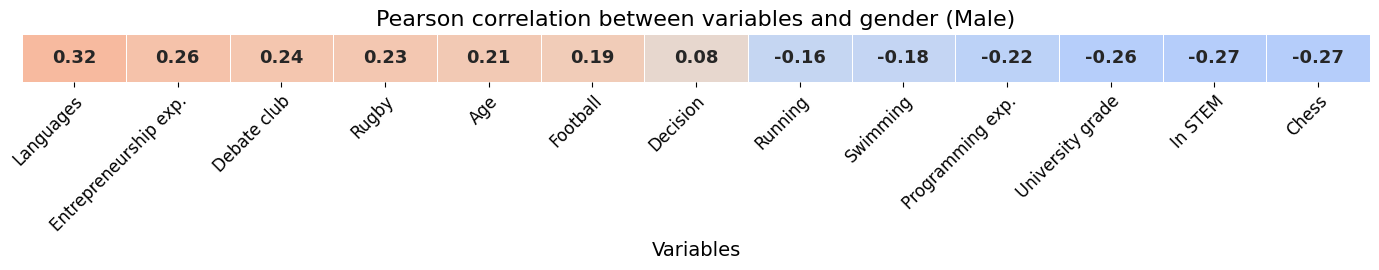

In [1040]:
### Correlation Matrix for target
target_col = "gender_male"

y = data_eda[target_col].astype(int)
X = data_eda.drop(columns=[target_col, 'gender_female'])


alpha = 0.05
corrected_alpha = alpha / X.shape[1]  # Bonferroni correction

results = []

for col in X.columns:
    x = X[col].astype(int)
    r, p = pearsonr(x, y)
    results.append({
        "variable": col,
        "correlation": r,
        "p": p
    })

corr_target = pd.DataFrame(results)

##Filter to only plot significant correlations
significant_corrs_gender = corr_target[corr_target["p"] < corrected_alpha]
significant_corrs_gender = significant_corrs_gender.sort_values("correlation", ascending=False)
corr_heatmap = significant_corrs_gender.set_index("variable")[["correlation"]]

## Plot the heatmap of significant correlations
fig, ax = plt.subplots(figsize=(14, 2.8))
sns.heatmap(
    corr_heatmap.T,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5, 
    cbar=False,
    annot_kws={"size": 13, "weight": "bold"},
    ax=ax
)

new_labels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]

ax.set_xticklabels(new_labels,rotation=45,ha="right",rotation_mode="anchor",fontsize=12)

plt.title("Pearson correlation between variables and gender (Male)", fontsize=16,)
plt.xlabel("Variables", fontsize=14)
#plt.ylabel("Pearson")
ax.set_yticklabels([])  
ax.tick_params(left=False)  

plt.tight_layout()
plt.show()

### Recruitment Outcome by Gender <a class="anchor" id="recr-outcome"></a>

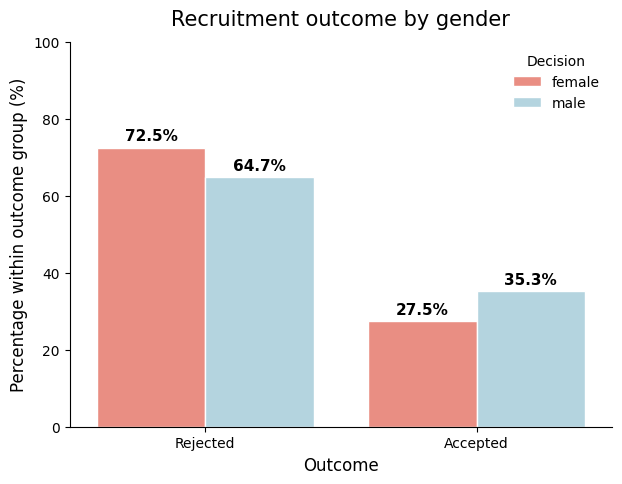

In [1041]:
# Count observations by gender and decision
plot_gender_decision_df = (df.groupby(["gender", "decision"]).size().reset_index(name="count"))

# Percentage
plot_gender_decision_df["percentage"] = (plot_gender_decision_df["count"] / plot_gender_decision_df.groupby("gender")["count"].transform("sum") * 100)

plot_gender_decision_df["decision_label"] = plot_gender_decision_df["decision"].map({False: "Rejected",True: "Accepted"})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=plot_gender_decision_df,
    x="decision_label",
    y="percentage",
    hue="gender",
    edgecolor="white", 
    palette={
        "female": "salmon",
        "male": "lightblue"
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Recruitment outcome by gender", fontsize=15, pad=12)
ax.set_xlabel("Outcome", fontsize=12)
ax.set_ylabel("Percentage within outcome group (%)", fontsize=12)
ax.set_ylim(0, 100)

##Remove the box around the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title="Decision", frameon=False)

plt.show()

## Baseline Model <a class="anchor" id="baseline-model"></a>

### Training <a class="anchor" id="bm-train"></a>

In [1042]:
## Check distribution of target variable across groups in train and test set
train_df = pd.DataFrame({
    'gender': group_train,
    'decision': y_train
})

percent_train = (
    train_df.groupby('gender')['decision'].mean() * 100
).reset_index(name='percent_chosen')

test_df = pd.DataFrame({
    'gender': group_test,
    'decision': y_test
})

percent_test = (
    test_df.groupby('gender')['decision'].mean() * 100
).reset_index(name='percent_chosen')


print(percent_train)
print('----')
print(percent_test)

   gender  percent_chosen
0  female       27.731674
1    male       35.921755
----
   gender  percent_chosen
0  female       26.453488
1    male       32.727273


In [1043]:
## Standardize numerical features and add them to a df
num_col = ["age", "ind-university_grade", "ind-languages"]

preprocessor = ColumnTransformer(
    transformers=[("scale_agep", StandardScaler(), num_col)],
    remainder="passthrough",
    verbose_feature_names_out=False
)

Xtr = preprocessor.fit_transform(X_train)
Xte = preprocessor.transform(X_test)

feat_names = preprocessor.get_feature_names_out()

Xtr_df = pd.DataFrame(Xtr, columns=feat_names, index=X_train.index)
Xte_df = pd.DataFrame(Xte, columns=feat_names, index=X_test.index)

In [1044]:
## Train a logistic regression model
log_baseline = LogisticRegressionCV(max_iter=5000, cv=5)
log_baseline.fit(Xtr, y_train)

## Extract coeff
beta = np.r_[log_baseline.intercept_, log_baseline.coef_.ravel()]

## Model prediction
y_pred_logistic = log_baseline.predict(Xte) 

## Save to a df for bias analysis
df_logistic = Xte_df
df_logistic['pred'] = y_pred_logistic
df_logistic['target'] = y_test


### Model Evaluation <a id="bm-model_evaluation"></a>

In [1045]:
## print classification report
accuracy_baseline = log_baseline.score(Xte, y_test)
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

       False       0.78      0.86      0.82       549
        True       0.58      0.43      0.50       235

    accuracy                           0.73       784
   macro avg       0.68      0.65      0.66       784
weighted avg       0.72      0.73      0.72       784



### Fairness Evaluation <a id="bm-fairness-evaluation"></a>


Statistical Parity <br>
$\Pr(S = 1 \mid G = 1) = \Pr(S = 1 \mid G = 0)$

In [1046]:
# Set env variables
group_male_label = False
group_fem_label = not group_male_label

group_col = 'gender_female'
selection_col = 'pred'
target_col = 'target'

In [1047]:
# Function that calcualtes statistical parity based on different groups
def statistical_parity(df, group):
    current_group = df[df[group_col] == group]
    true_current_group = current_group[current_group[selection_col]]
    return true_current_group.shape[0]/current_group.shape[0]

In [1048]:
fem_sp_bef = statistical_parity(df_logistic, group=group_fem_label)
male_sp_bef = statistical_parity(df_logistic, group=group_male_label)

print("Statistical Parity (Baseline Model)")
print(f'Female rate: {fem_sp_bef*100:.2f}%')
print(f'Male rate: {male_sp_bef*100:.2f}%')
print(f'Ratio (F/M): {fem_sp_bef/male_sp_bef:.2f}')

stats_parity_diff = male_sp_bef - fem_sp_bef

print(f'Diff (M-F): {stats_parity_diff:.2f}')

Statistical Parity (Baseline Model)
Female rate: 12.79%
Male rate: 30.23%
Ratio (F/M): 0.42
Diff (M-F): 0.17


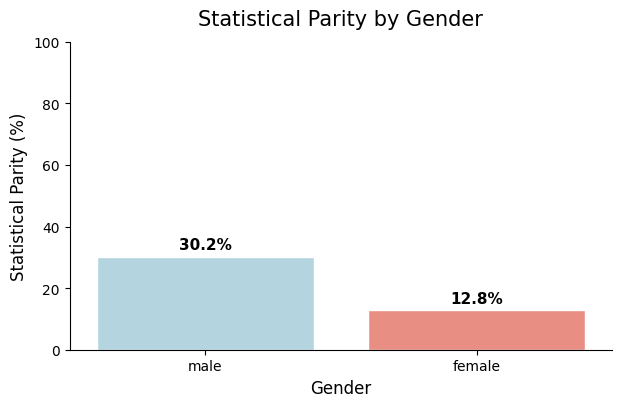

In [1049]:
# Create dataframe for plotting
sp_df = pd.DataFrame({
    "gender": ["male", "female"],
    "statistical_parity": [male_sp_bef * 100, fem_sp_bef * 100]
})

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=sp_df,
    x="gender",
    y="statistical_parity",
    hue="gender",
    edgecolor="white",
    palette={
        "female": "salmon",
        "male": "lightblue"
    },
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Statistical Parity by Gender",
    fontsize=15,
    pad=12
)

ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Statistical Parity (%)", fontsize=12)

ax.set_ylim(0, 100)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

## Fairness Intervention: Removing Gender Feature <a class="anchor" id="removing-gender"></a>

### Train <a class="anchor" id="rg-train"></a>

In [1050]:
## Load the data without the protected attribute
X_train_no_gender = X_train.drop(columns= ["gender_female"])
X_test_no_gender = X_test.drop(columns= ["gender_female"])

num_col = ["age", "ind-university_grade", "ind-languages"]

## Standardize numerical features
Xtr_no_gender = preprocessor.fit_transform(X_train_no_gender)
Xte_no_gender = preprocessor.transform(X_test_no_gender)

feat_names = preprocessor.get_feature_names_out()

Xtr_df_no_gender = pd.DataFrame(Xtr_no_gender, columns=feat_names, index=X_train_no_gender.index)
Xte_df_no_gender = pd.DataFrame(Xte_no_gender, columns=feat_names, index=X_test_no_gender.index)


## Train a logistic regression model without the protected attribute
log_no_gender = LogisticRegressionCV(max_iter=5000, cv=5)  
log_no_gender.fit(Xtr_no_gender, y_train)

## Model prediction
y_pred_logistic_no_gender = log_no_gender.predict(Xte_no_gender)   

## Save to a df for bias analysis
df_logistic_no_gender = X_test.copy()
df_logistic_no_gender['pred_no_gender'] = y_pred_logistic_no_gender
df_logistic_no_gender['target'] = y_test

### Model Evaluation <a class="anchor" id="rg-model-evaluation"></a>

In [1051]:
## print classification report and accuracy
accuracy_no_gender = log_no_gender.score(Xte_no_gender, y_test)
print(f'accuracy scale: {accuracy_no_gender}')
print(classification_report(y_test, y_pred_logistic_no_gender))

accuracy scale: 0.7385204081632653
              precision    recall  f1-score   support

       False       0.78      0.87      0.82       549
        True       0.58      0.44      0.50       235

    accuracy                           0.74       784
   macro avg       0.68      0.65      0.66       784
weighted avg       0.72      0.74      0.73       784



### Fairness Evaluation <a class="anchor" id="rg-fairness-evaluation"></a>

In [1052]:
selection_col = 'pred_no_gender'

fem_sp_bef_no_gender = statistical_parity(df_logistic_no_gender, group=group_fem_label)
male_sp_bef_no_gender = statistical_parity(df_logistic_no_gender, group=group_male_label)

print("Statistical Parity (After Removing Gender)")
print(f'Female rate: {fem_sp_bef_no_gender*100:.2f}%')
print(f'Male rate: {male_sp_bef_no_gender*100:.2f}%')
print(f'Ratio (F/M): {fem_sp_bef_no_gender/male_sp_bef_no_gender:.2f}')

stats_parity_diff_no_gender = male_sp_bef_no_gender - fem_sp_bef_no_gender

print(f'Diff (M-F): {stats_parity_diff_no_gender:.2f}')

Statistical Parity (After Removing Gender)
Female rate: 14.24%
Male rate: 29.32%
Ratio (F/M): 0.49
Diff (M-F): 0.15


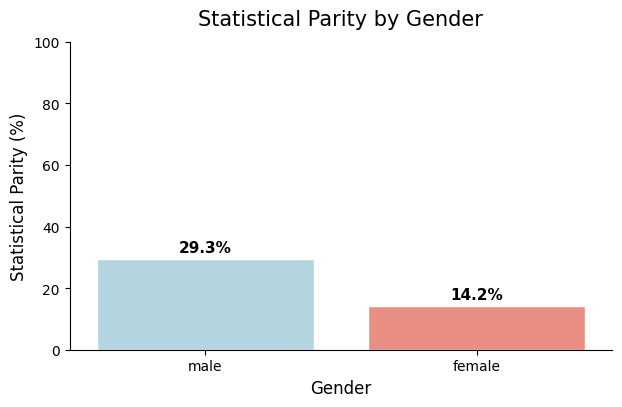

In [1053]:
# Create dataframe for plotting
sp_df = pd.DataFrame({
    "gender": ["male", "female"],
    "statistical_parity": [male_sp_bef_no_gender * 100, fem_sp_bef_no_gender * 100]
})

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=sp_df,
    x="gender",
    y="statistical_parity",
    hue="gender",
    edgecolor="white",
    palette={
        "female": "salmon",
        "male": "lightblue"
    },
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Statistical Parity by Gender",
    fontsize=15,
    pad=12
)

ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Statistical Parity (%)", fontsize=12)

ax.set_ylim(0, 100)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

## Fairness Intervention: Fair PCA Transformation <a class="anchor" id="fair-pca"></a>


###  Baseline Correlation Analysis <a class="anchor" id="correlations-1"></a>

In [1054]:
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

## Move the gender (female) column to the end of the dataframe and drop the original one
X_train_copy['gender'] = X_train_copy['gender_female']
X_test_copy['gender'] = X_test_copy['gender_female']

X_train_copy.drop(columns=["gender_female"], inplace=True)
X_test_copy.drop(columns=["gender_female"], inplace=True)

X_train_copy.rename(columns={'gender': 'gender_female'}, inplace=True)
X_test_copy.rename(columns={'gender': 'gender_female'}, inplace=True)

In [1055]:
X_train_copy.columns

Index(['age', 'ind-university_grade', 'ind-debateclub', 'ind-programming_exp',
       'ind-international_exp', 'ind-entrepeneur_exp', 'ind-languages',
       'ind-exact_study', 'nationality_Belgian', 'nationality_German',
       'sport_Chess', 'sport_Cricket', 'sport_Golf', 'sport_Rugby',
       'sport_Running', 'sport_Swimming', 'sport_Tennis', 'ind-degree_master',
       'ind-degree_phd', 'company_B', 'company_C', 'company_D',
       'gender_female'],
      dtype='object')

In [1056]:
# Scale all features (even OHE)
scaler = StandardScaler().fit(X_train_copy)
Xs_train = scaler.transform(X_train_copy)
Xs_test = scaler.transform(X_test_copy)
n_features = X_train_copy.shape[1]

In [1057]:
# Subset for protected and non-protected features
n = 22
Xs_train_p = Xs_train[:, n:]
Xs_test_p = Xs_test[:, n:]
Xs_train_np = Xs_train[:, :n]
Xs_test_np = Xs_test[:, :n]

In [1058]:
n_features = X_train.shape[1]
alpha = 0.05 # Significance level
corrected_alpha = alpha / (n_features**2/2) # Bonferroni correction for multiple testings

# Compute correlation matrix
corr = np.zeros((n_features, n_features))
p = np.zeros((n_features, n_features))
for i in range(n_features):
    for j in range(n_features):
        corr[i,j], p[i,j] = pearsonr(Xs_train[:,i], Xs_train[:,j])
        if np.isnan(corr[i,j]):
            p[i,j] = 1

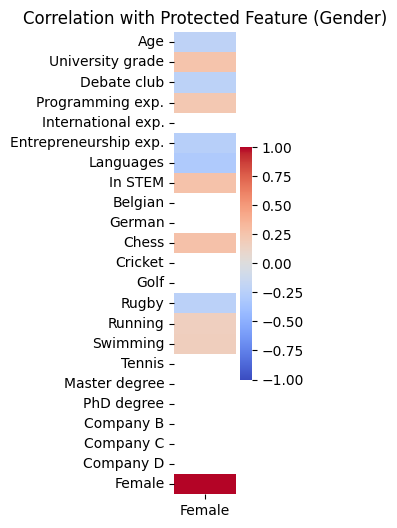

In [1079]:
# Get original labels
x_labels = X_train_copy.columns[n:]
y_labels = X_train_copy.columns

# Apply mapping (fallback to original name if not in dict)
x_labels = [label_map.get(col, col) for col in x_labels]
y_labels = [label_map.get(col, col) for col in y_labels]

plt.figure(figsize=(1, 6))

sns.heatmap(
    corr[:, n:],
    cmap="coolwarm",
    xticklabels=x_labels,
    yticklabels=y_labels,
    mask=p[:, n:] > corrected_alpha,
    vmin=-1,
    vmax=1
)

plt.title("Correlation with Protected Feature (Gender)")
plt.show()

### Fair PCA Implementation <a id="fair-pca-implementation"></a>

In [1060]:
class FairPCA:
    def __init__(self, Xs, p_idxs, n_components, Y, fairness_metric = "statistical_parity"):
        self.fairness_metric = fairness_metric
        self.fit(Xs, p_idxs, n_components, fairness_metric, Y)

    def fit(self, Xs, p_idxs, n_components, fairness_metric, Y):
        # Extract protected features
        Xs_p = Xs[:, p_idxs]

        if self.fairness_metric == "statistical_parity": 
            pass
        elif self.fairness_metric == "equalised_odds": # Equal Opportunity
            Xs_p = Xs_p[Y == 1]
            Xs = Xs[Y == 1]
        else:
            print("Fairness metric not supported. Please choose between 'statistical_parity' and 'equalised_odds'.")

        # Compute projection matrix (U)
        Z = Xs_p
        #Z = Z - Z.mean(0) # Since we already standardised everything, there is not much sense in removing the mean
        R = scipy.linalg.null_space(Z.T @ Xs)
        eig_vals, L = scipy.linalg.eig(R.T @ Xs.T @ Xs @ R)
        self.U = R @ L[:, :n_components]
        self.eig_vals = eig_vals

    def project(self, Xs):
        return Xs @ self.U
    
n_components = Xs_train.shape[1] - 1 # number of features - number of protected
fair_pca = FairPCA(Xs_train, [n], n_components, y_train)
Xs_train_debiased = fair_pca.project(Xs_train)
Xs_test_debiased = fair_pca.project(Xs_test)

In [1061]:
# Check normalized eigenvalues
percent_var_eig = np.sort(fair_pca.eig_vals) / np.sum(fair_pca.eig_vals)
percent_var_eig

array([0.00999203+0.j, 0.01160316+0.j, 0.01583588+0.j, 0.01609107+0.j,
       0.02021418+0.j, 0.02095825+0.j, 0.02172567+0.j, 0.02997612+0.j,
       0.03848712+0.j, 0.04262156+0.j, 0.04506201+0.j, 0.05143755+0.j,
       0.0525012 +0.j, 0.05335649+0.j, 0.05395997+0.j, 0.05800512+0.j,
       0.06079436+0.j, 0.06402056+0.j, 0.06604025+0.j, 0.06851858+0.j,
       0.09456771+0.j, 0.10423116+0.j])

### Post Transformation Correlations <a id="correlations-aft"></a>

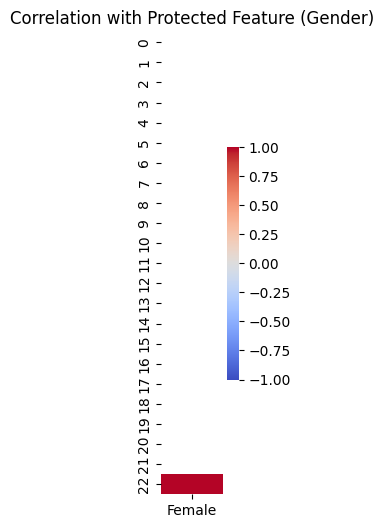

In [ ]:
# Compute correlation matrix
Xs_train_debiased_p = np.concatenate([Xs_train_debiased, Xs_train_p], axis=1)

n_features = Xs_train_debiased_p.shape[1]

corr_ = np.zeros((n_features, n_features))
p_ = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(n_features):
        corr_[i, j], p_[i, j] = pearsonr(
            Xs_train_debiased_p[:, i],
            Xs_train_debiased_p[:, j]
        )

corr_ = np.nan_to_num(corr_, nan=0)

x_label = X_train_copy.columns[-1]
x_label = "Female" if x_label == "gender_female" else x_label

# Plot correlations with protected features
plt.figure(figsize=(1, 6))

sns.heatmap(
    corr_[:, -1:],
    cmap="coolwarm",
    xticklabels=[x_label],
    mask=p_[:, -1:] > corrected_alpha,
    vmin=-1,
    vmax=1
)

plt.title("Correlation with Protected Feature (Gender)")
plt.show()

In [1063]:
group_test_dict = {
    'Males': group_test == 'male',
    'Females': group_test  == 'female',
}

### Training & Model Evaluation <a id="fp-train-model-evaluation"></a>

In [1064]:
# Fit model and predict
model = LogisticRegression(penalty=None, max_iter=5000)
model.fit(Xs_train_debiased, y_train)
y_hat = model.predict(Xs_test_debiased)
## print classification report and accuracy
accuracy_debiased = model.score(Xs_test_debiased, y_test)
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

       False       0.78      0.88      0.83       549
        True       0.59      0.42      0.49       235

    accuracy                           0.74       784
   macro avg       0.69      0.65      0.66       784
weighted avg       0.72      0.74      0.73       784



In [1065]:
df_log_pca = X_test.copy()
df_log_pca['pred'] = y_hat

### Fairness Evaluation <a id="fp-fairness-evaluation"></a>

In [1066]:
selection_col = 'pred'

fem_sp_pca = statistical_parity(df_log_pca, group=group_fem_label)
male_sp_pca = statistical_parity(df_log_pca, group=group_male_label)

print("Statistical Parity (After Fair PCA)")
print(f'Female rate: {fem_sp_pca*100:.2f}%')
print(f'Male rate: {male_sp_pca*100:.2f}%')
print(f'Ratio (F/M): {fem_sp_pca/male_sp_pca:.2f}')

stats_parity_diff_pca = male_sp_pca - fem_sp_pca

print(f'Diff (M-F): {stats_parity_diff_pca:.2f}')

Statistical Parity (After Fair PCA)
Female rate: 17.15%
Male rate: 24.55%
Ratio (F/M): 0.70
Diff (M-F): 0.07


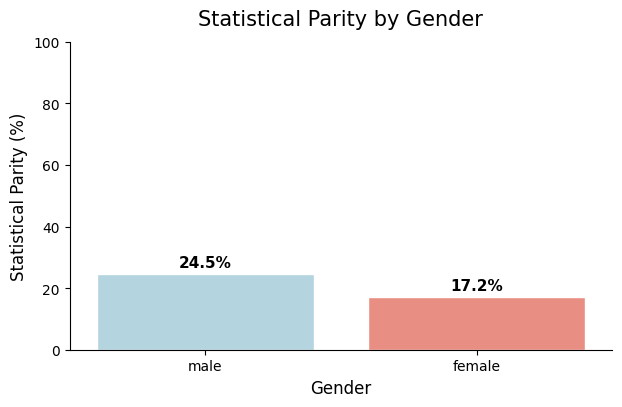

In [1067]:
# Create dataframe for plotting
sp_df = pd.DataFrame({
    "gender": ["male", "female"],
    "statistical_parity": [male_sp_pca * 100, fem_sp_pca * 100]
})

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=sp_df,
    x="gender",
    y="statistical_parity",
    hue="gender",
    edgecolor="white",
    palette={
        "female": "salmon",
        "male": "lightblue"
    },
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Statistical Parity by Gender",
    fontsize=15,
    pad=12
)

ax.set_xlabel("Gender", fontsize=12)
ax.set_ylabel("Statistical Parity (%)", fontsize=12)

ax.set_ylim(0, 100)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

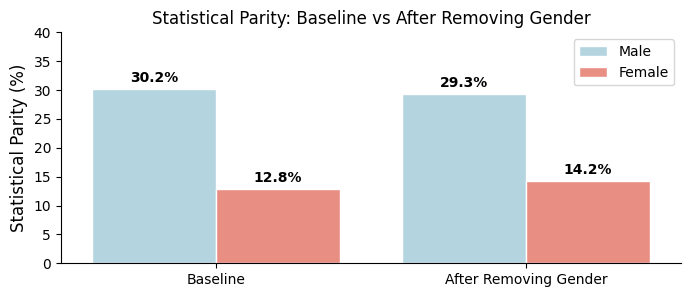

In [1068]:
# Create dataframe
sp_comparison_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "After Removing Gender",
        "Baseline",
        "After Removing Gender"
    ],
    "Gender": [
        "Male", "Male",
        "Female", "Female"
    ],
    "Statistical_Parity": [
        male_sp_bef * 100,
        male_sp_bef_no_gender * 100,
        fem_sp_bef * 100,
        fem_sp_bef_no_gender * 100
    ]
})

plt.figure(figsize=(8, 3))

ax = sns.barplot(
    data=sp_comparison_df,
    x="Model",
    y="Statistical_Parity",
    hue="Gender",
    edgecolor="white",
    palette={
        "Female": "salmon",
        "Male": "lightblue"
    }
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylabel("Statistical Parity (%)", fontsize=12)
ax.set_xlabel("")  # Remove x-axis label

ax.set_ylim(0, 40)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("Statistical Parity: Baseline vs After Removing Gender")

ax.legend(frameon=True)

plt.show()

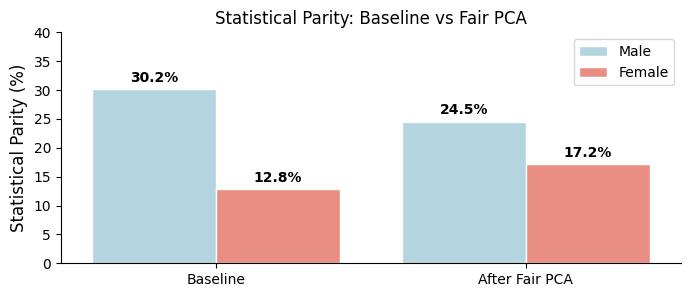

In [1069]:
# Create dataframe
sp_comparison_df = pd.DataFrame({
    "Model": [
        "Baseline",
        "After Fair PCA",
        "Baseline",
        "After Fair PCA"
    ],
    "Gender": [
        "Male", "Male",
        "Female", "Female"
    ],
    "Statistical_Parity": [
        male_sp_bef * 100,
        male_sp_pca * 100,
        fem_sp_bef * 100,
        fem_sp_pca * 100
    ]
})

plt.figure(figsize=(8, 3))

ax = sns.barplot(
    data=sp_comparison_df,
    x="Model",
    y="Statistical_Parity",
    hue="Gender",
    edgecolor="white",
    palette={
        "Female": "salmon",
        "Male": "lightblue"
    }
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylabel("Statistical Parity (%)", fontsize=12)
ax.set_xlabel("")  # Remove x-axis label

ax.set_ylim(0, 40)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=True)
ax.set_title("Statistical Parity: Baseline vs Fair PCA")

plt.show()

## Fair PCA Robustness: Effect of Gender Flipping on SHAP Explanations <a class="anchor" id="pca-robustness"></a>

### Flip Gender in Test Data <a class="anchor" id="flip-gender"></a>

In [1070]:
dummy_test_copy = X_test_copy.copy()
dummy_test_copy['gender_female'] = ~dummy_test_copy['gender_female'] # flip gender

Xs_dummy_test_copy = scaler.transform(dummy_test_copy)
Xs_dummy_test_debiased_copy = fair_pca.project(Xs_dummy_test_copy)
pca_columns=[f'feat{x}' for x in range(1,23)]
df_Xs_dummy_test_debiased_copy = pd.DataFrame(Xs_dummy_test_debiased_copy, columns=pca_columns)

In [1071]:
# We swapped the genders
group_test_dict_dummy = {
    'Females_fake': group_test == 'male', #these are actually males, but we flipped them to be female for the experiment
    'Males_fake': group_test  == 'female', # these are actually female, but we flipped them to be male
}

In [1072]:
y_hat_dummy = model.predict(Xs_dummy_test_debiased_copy)

### Model Evaluation  <a class="anchor" id="fg-model-evaluation"></a>

In [1073]:
## print classification report and accuracy
accuracy_debiased_dummy = model.score(Xs_dummy_test_debiased_copy, y_test)
print(f'Accuracy after flipping gender: {accuracy_debiased_dummy}')
print(classification_report(y_test, y_hat_dummy))


# Calculate and print F1 Scores for each group https://en.wikipedia.org/wiki/F-score
for group, group_idxs in group_test_dict_dummy.items():
    print(f'F1, {group}: {f1_score(y_test[group_idxs], y_hat_dummy[group_idxs]):.2f}')
print("\n")
# Calculate and print selection rates for each group
for group, group_idxs in group_test_dict_dummy.items():
    print(f'Selection Rate, {group}: {np.mean(y_hat_dummy[group_idxs]):.2f}')
print("\n")
# Calculate and print true positive rates for each group
for group, group_idxs in group_test_dict_dummy.items():
    print(f'True Positive Rate, {group}: {np.mean(y_hat_dummy[group_idxs][y_test[group_idxs] == 1]):.2f}')
print("\n")
# Calculate and print false positive rates for each group
for group, group_idxs in group_test_dict_dummy.items():
    print(f'False Positive Rate, {group}: {np.mean(y_hat_dummy[group_idxs][y_test[group_idxs] == 0]):.2f}')

Accuracy after flipping gender: 0.7283163265306123
              precision    recall  f1-score   support

       False       0.78      0.85      0.81       549
        True       0.56      0.44      0.49       235

    accuracy                           0.73       784
   macro avg       0.67      0.65      0.65       784
weighted avg       0.71      0.73      0.72       784

F1, Females_fake: 0.57
F1, Males_fake: 0.31


Selection Rate, Females_fake: 0.34
Selection Rate, Males_fake: 0.11


True Positive Rate, Females_fake: 0.58
True Positive Rate, Males_fake: 0.22


False Positive Rate, Females_fake: 0.22
False Positive Rate, Males_fake: 0.07


We see that compared to the initial evaluation of the fair PCA model that the males that are now percieved as female (female_fake) are now scoring higher than they did before their gender was swapped. This happens in all metrics.
The opposite happens for the females that are now percieved as male (male_fale), as they are scoring lower than before on all metrics.
It appears that having 'gender' = True (so the model thinks the person is female) increases the probability of getting recruited, and having 'gender'=False (model thinks the person is male) decreases the probability of getting recruited.

### Fairness Evaluation  <a class="anchor" id="fg-fairness-evaluation"></a>

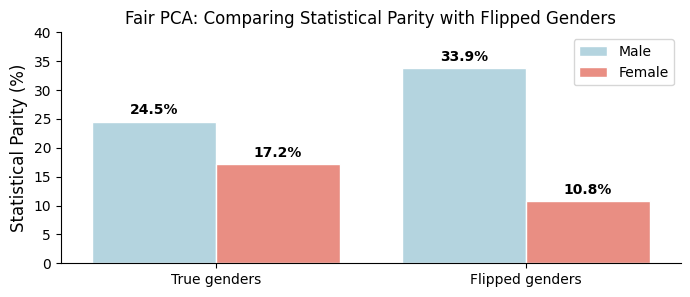

In [1074]:
# Plotting the change in classification when Fair PCA is given the actual gender of a person versus giving the opposite gender

df_log_pca_dummy = dummy_test_copy.copy()
df_log_pca_dummy['pred'] = y_hat_dummy

group_col = 'gender_female'
selection_col = 'pred'

male_sp_bef_dummy = statistical_parity(df_log_pca_dummy, group=group_fem_label) # These are actually male, their dummy label "female" was the flipped gender
fem_sp_bef_dummy = statistical_parity(df_log_pca_dummy, group=group_male_label) # These are actually female, their dummy label "male" was the flipped gender

# Create dataframe
sp_comparison_df = pd.DataFrame({
    "Model": [
        "True genders",
        "Flipped genders",
        "True genders",
        "Flipped genders"
    ],
    "Gender": [
        "Male", "Male",
        "Female", "Female"
    ],
    "Statistical_Parity": [
        male_sp_pca * 100,
        male_sp_bef_dummy * 100,
        fem_sp_pca * 100,
        fem_sp_bef_dummy * 100
    ]
})


plt.figure(figsize=(8, 3))

ax = sns.barplot(
    data=sp_comparison_df,
    x="Model",
    y="Statistical_Parity",
    hue="Gender",
    edgecolor="white",
    palette={
        "Female": "salmon",
        "Male": "lightblue"
    }
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylabel("Statistical Parity (%)", fontsize=12)
ax.set_xlabel("")  # Remove x-axis label

ax.set_ylim(0, 40)

# Remove top/right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=True)

ax.set_title('Fair PCA: Comparing Statistical Parity with Flipped Genders')


plt.show()

### SHAP Comparison: Original vs Gender-Flipped Test Instances  <a class="anchor" id="fg-shap"></a>

In [1075]:
df_Xs_train_debiased = pd.DataFrame(Xs_train_debiased, columns=pca_columns)
df_Xs_test_debiased = pd.DataFrame(Xs_test_debiased, columns=pca_columns)

In [1076]:
shap.initjs()

explainer_pca = shap.KernelExplainer(model=model.predict, data=df_Xs_train_debiased)

# get shapley values for one instance
shap_values_pca_true = explainer_pca.shap_values(df_Xs_test_debiased.iloc[0,:])
shap_values_pca_flipped = explainer_pca.shap_values(df_Xs_dummy_test_debiased_copy.iloc[0,:])

Using 3133 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


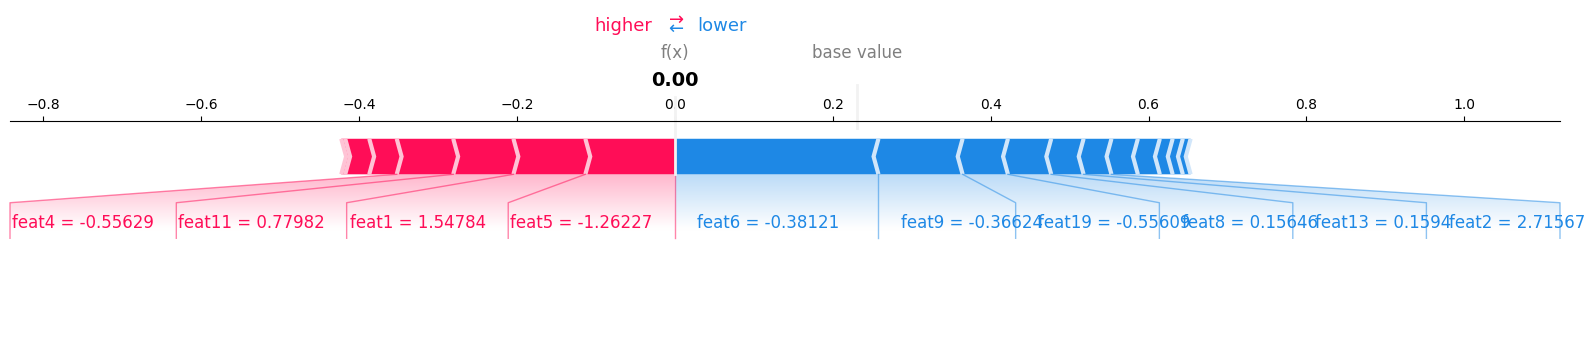

In [1077]:
# Force plot of the first row in test, with the true gender
shap.force_plot(explainer_pca.expected_value, shap_values_pca_true, df_Xs_test_debiased.iloc[0,:].round(5), matplotlib=True)

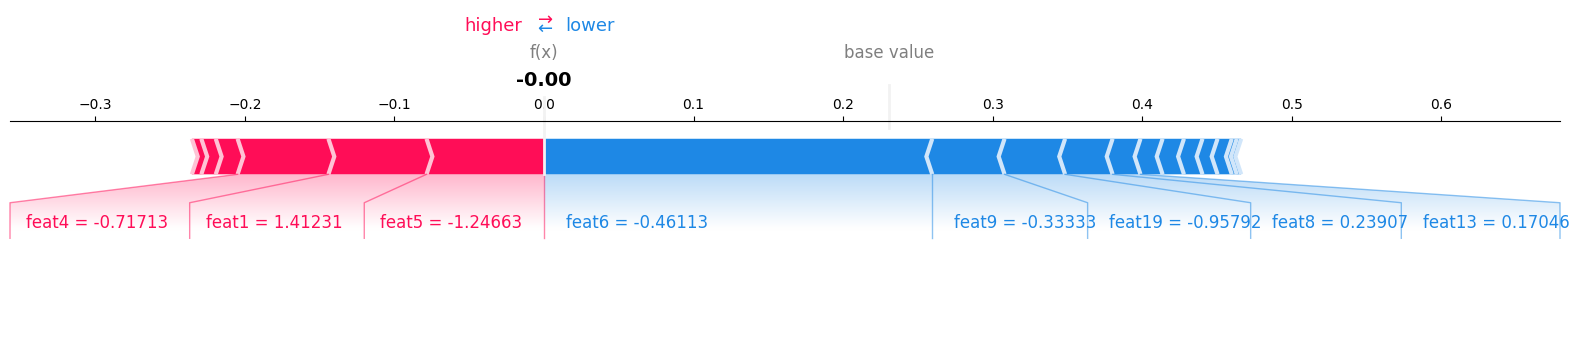

In [1078]:
# Force plot of the first row in test, with the flipped gender
shap.force_plot(explainer_pca.expected_value, shap_values_pca_flipped, df_Xs_dummy_test_debiased_copy.iloc[0,:].round(5), matplotlib=True)